In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from tensorboardX import SummaryWriter
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score

In [2]:
df = pd.read_csv("food_security_dataset.csv")
df.head()

,year,province,district,district_pcode,food_insecure_pct,risk_class,label_source,is_survey_year,last_survey_food_insecure_pct,rain_12m_mm,...,sas_inorganic_fert_plots_pct,sas_inorganic_kg_ha,sas_dap_kg_ha,sas_urea_kg_ha,sas_npk_kg_ha,sas_n_seasons,sas_maize_yield_change_pct,sas_beans_yield_change_pct,sas_cassava_yield_change_pct,sas_irish_potato_yield_change_pct
0,2006,Kigali City,Nyarugenge,RW11,2.46,low,backfilled,False,NaN,1056.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,Kigali City,Gasabo,RW12,23.71,medium,fcs_proxy_survey,True,NaN,1041.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Kigali City,Kicukiro,RW13,7.61,low,fcs_proxy_survey,True,NaN,999.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,Southern Province,Nyanza,RW21,31.56,high,fcs_proxy_survey,True,NaN,1028.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,Southern Province,Gisagara,RW22,35.49,high,fcs_proxy_survey,True,NaN,1053.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# get columns names
df.columns

Index(['year', 'province', 'district', 'district_pcode', 'food_insecure_pct',
       'risk_class', 'label_source', 'is_survey_year',
       'last_survey_food_insecure_pct', 'rain_12m_mm', 'rain_n_dry_months',
       'rain_n_wet_months', 'rain_max_month_mm', 'rain_12m_pct_normal',
       'rain_seasonB_mm', 'rain_seasonB_pct_normal', 'rain_seasonB_zscore',
       'rain_seasonA_mm', 'rain_seasonA_pct_normal', 'rain_seasonA_zscore',
       'temp_12m_c', 'temp_max_month_c', 'temp_12m_anomaly_c',
       'temp_seasonB_c', 'temp_seasonB_anomaly_c', 'temp_seasonA_c',
       'temp_seasonA_anomaly_c', 'price_beans_rwf_kg', 'price_beans_yoy_pct',
       'price_level', 'price_maize_rwf_kg', 'price_maize_yoy_pct',
       'price_cassava_flour_rwf_kg', 'price_cassava_flour_yoy_pct',
       'price_irish_potato_rwf_kg', 'price_irish_potato_yoy_pct',
       'price_sorghum_rwf_kg', 'price_sorghum_yoy_pct',
       'sas_maize_yield_kg_ha', 'sas_maize_production_t', 'sas_maize_area_ha',
       'sas_beans_yie

In [4]:
# describe the dataset
df.describe(include="all")

/home/aggie/Desktop/formative 2/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,year,province,district,district_pcode,food_insecure_pct,risk_class,label_source,is_survey_year,last_survey_food_insecure_pct,rain_12m_mm,...,sas_inorganic_fert_plots_pct,sas_inorganic_kg_ha,sas_dap_kg_ha,sas_urea_kg_ha,sas_npk_kg_ha,sas_n_seasons,sas_maize_yield_change_pct,sas_beans_yield_change_pct,sas_cassava_yield_change_pct,sas_irish_potato_yield_change_pct
count,630.000000,630,630,630,570.000000,570,630,630,594.000000,630.000000,...,390.000000,300.000000,300.000000,300.000000,300.000000,390.000000,270.000000,270.000000,269.00,267.000000
unique,NaN,5,30,30,NaN,3,5,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Southern Province,Nyarugenge,RW11,NaN,medium,interpolated,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,168,21,21,NaN,272,358,424,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2016.000000,NaN,NaN,NaN,19.996386,NaN,NaN,NaN,20.523990,1169.001746,...,25.892538,70.859833,17.678433,17.262367,27.917267,2.861538,2.105778,5.187481,inf,2.088202
std,6.060112,NaN,NaN,NaN,10.551332,NaN,NaN,NaN,11.188754,182.561971,...,14.296860,89.356327,18.834662,29.884706,64.208767,0.345827,32.108557,34.304060,NaN,36.563371
min,2006.000000,NaN,NaN,NaN,1.190000,NaN,NaN,NaN,1.190000,739.500000,...,0.000000,1.750000,0.390000,0.580000,0.080000,2.000000,-64.320000,-53.970000,-100.00,-91.480000
25%,2011.000000,NaN,NaN,NaN,12.162500,NaN,NaN,NaN,11.570000,1029.150000,...,14.967500,23.282500,6.707500,6.620000,4.320000,3.000000,-18.140000,-18.812500,-16.01,-20.050000
50%,2016.000000,NaN,NaN,NaN,19.055000,NaN,NaN,NaN,19.590000,1162.350000,...,23.370000,40.080000,12.230000,10.335000,8.920000,3.000000,-2.965000,-2.430000,23.78,-1.500000
75%,2021.000000,NaN,NaN,NaN,26.755000,NaN,NaN,NaN,27.480000,1291.275000,...,35.762500,80.875000,20.717500,16.562500,20.615000,3.000000,19.512500,27.870000,106.28,19.160000


In [5]:
# check data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 75 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               630 non-null    int64  
 1   province                           630 non-null    str    
 2   district                           630 non-null    str    
 3   district_pcode                     630 non-null    str    
 4   food_insecure_pct                  570 non-null    float64
 5   risk_class                         570 non-null    str    
 6   label_source                       630 non-null    str    
 7   is_survey_year                     630 non-null    bool   
 8   last_survey_food_insecure_pct      594 non-null    float64
 9   rain_12m_mm                        630 non-null    float64
 10  rain_n_dry_months                  630 non-null    int64  
 11  rain_n_wet_months                  630 non-null    int64  
 12  rain_

In [6]:
# check for nan values
df.isna().sum()

year                                   0
province                               0
district                               0
district_pcode                         0
food_insecure_pct                     60
                                    ... 
sas_n_seasons                        240
sas_maize_yield_change_pct           360
sas_beans_yield_change_pct           360
sas_cassava_yield_change_pct         361
sas_irish_potato_yield_change_pct    363
Length: 75, dtype: int64

In [7]:
nan_table = pd.DataFrame({
    "nan_count": df.isna().sum(),
    "nan_pct": (df.isna().mean() * 100).round(1),
}).sort_values("nan_pct", ascending=False)

nan_table[nan_table["nan_count"] > 0]

,nan_count,nan_pct
sas_worse_harvest_pct,480,76.2
sas_beans_production_t,450,71.4
sas_sweet_potato_production_t,450,71.4
sas_banana_production_t,450,71.4
sas_cassava_production_t,450,71.4
sas_sorghum_production_t,450,71.4
sas_irish_potato_production_t,450,71.4
sas_maize_production_t,450,71.4
sas_rice_production_t,450,71.4
sas_rice_yield_kg_ha,440,69.8


For this baseline model, we are going to remove features with more than 50% of missing values

In [8]:
threshold_nan = 50
feature_to_remove = nan_table.index[nan_table["nan_pct"] > threshold_nan].to_list()
drop = sorted(set(feature_to_remove))
print(f"Number of features to drop for too many missing values: {len(drop)}")

Number of features to drop for too many missing values: 33


In [9]:
df_clean = df.drop(columns=drop)
df_clean.head()

,year,province,district,district_pcode,food_insecure_pct,risk_class,label_source,is_survey_year,last_survey_food_insecure_pct,rain_12m_mm,...,price_cassava_flour_rwf_kg,price_cassava_flour_yoy_pct,price_irish_potato_rwf_kg,price_irish_potato_yoy_pct,price_sorghum_rwf_kg,price_sorghum_yoy_pct,sas_improved_seed_pct,sas_sold_pct,sas_inorganic_fert_plots_pct,sas_n_seasons
0,2006,Kigali City,Nyarugenge,RW11,2.46,low,backfilled,False,NaN,1056.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,Kigali City,Gasabo,RW12,23.71,medium,fcs_proxy_survey,True,NaN,1041.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Kigali City,Kicukiro,RW13,7.61,low,fcs_proxy_survey,True,NaN,999.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,Southern Province,Nyanza,RW21,31.56,high,fcs_proxy_survey,True,NaN,1028.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,Southern Province,Gisagara,RW22,35.49,high,fcs_proxy_survey,True,NaN,1053.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We are removing some columns because some of them are mainly used for identification purposes and do not add much in the problem

In [10]:
df_clean.iloc[:, 23:]

,temp_seasonB_c,temp_seasonB_anomaly_c,temp_seasonA_c,temp_seasonA_anomaly_c,price_beans_rwf_kg,price_beans_yoy_pct,price_level,price_maize_rwf_kg,price_maize_yoy_pct,price_cassava_flour_rwf_kg,price_cassava_flour_yoy_pct,price_irish_potato_rwf_kg,price_irish_potato_yoy_pct,price_sorghum_rwf_kg,price_sorghum_yoy_pct,sas_improved_seed_pct,sas_sold_pct,sas_inorganic_fert_plots_pct,sas_n_seasons
0,20.24,0.42,20.28,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20.03,0.35,20.06,0.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20.79,0.35,20.94,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20.02,0.63,20.00,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20.34,0.60,20.52,0.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,20.97,0.46,21.11,0.69,776.12,1.33,district,516.16,34.50,726.36,-15.65,472.77,-8.30,688.16,11.00,8.34,63.08,30.27,2.0
626,21.59,0.49,21.83,0.79,801.17,4.11,province,545.53,41.99,726.37,-5.75,489.29,-8.57,734.20,9.77,11.00,90.14,25.83,2.0
627,21.34,0.34,21.73,0.66,822.90,6.63,district,576.08,50.10,724.37,3.06,506.67,-8.41,769.21,8.79,1.45,63.43,19.69,2.0
628,21.33,0.35,21.84,0.66,801.17,4.11,province,545.53,41.99,726.37,-5.75,489.29,-8.57,734.20,9.77,4.72,70.93,9.76,2.0


In [11]:
colums_to_remove = ["district_pcode	",
                    "label_source",
                    "is_survey_year",
                    "last_survey_food_insecure_pct",
                    "price_level",
                    "sas_n_seasons",
                    ]
duplicate_target = ["food_insecure_pct"]
drop_columns = [columns.strip() for columns in colums_to_remove + duplicate_target]

In [12]:
clean_df = df_clean.drop(columns=drop_columns)
clean_df.head()

,year,province,district,risk_class,rain_12m_mm,rain_n_dry_months,rain_n_wet_months,rain_max_month_mm,rain_12m_pct_normal,rain_seasonB_mm,...,price_maize_yoy_pct,price_cassava_flour_rwf_kg,price_cassava_flour_yoy_pct,price_irish_potato_rwf_kg,price_irish_potato_yoy_pct,price_sorghum_rwf_kg,price_sorghum_yoy_pct,sas_improved_seed_pct,sas_sold_pct,sas_inorganic_fert_plots_pct
0,2006,Kigali City,Nyarugenge,low,1056.0,2,2,207.0,102.73,371.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,Kigali City,Gasabo,medium,1041.2,2,2,216.3,102.56,372.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Kigali City,Kicukiro,low,999.3,1,2,206.0,101.76,349.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,Southern Province,Nyanza,high,1028.6,1,0,161.1,95.74,393.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,Southern Province,Gisagara,high,1053.1,2,0,171.6,90.53,411.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
clean_df.columns

Index(['year', 'province', 'district', 'risk_class', 'rain_12m_mm',
       'rain_n_dry_months', 'rain_n_wet_months', 'rain_max_month_mm',
       'rain_12m_pct_normal', 'rain_seasonB_mm', 'rain_seasonB_pct_normal',
       'rain_seasonB_zscore', 'rain_seasonA_mm', 'rain_seasonA_pct_normal',
       'rain_seasonA_zscore', 'temp_12m_c', 'temp_max_month_c',
       'temp_12m_anomaly_c', 'temp_seasonB_c', 'temp_seasonB_anomaly_c',
       'temp_seasonA_c', 'temp_seasonA_anomaly_c', 'price_beans_rwf_kg',
       'price_beans_yoy_pct', 'price_maize_rwf_kg', 'price_maize_yoy_pct',
       'price_cassava_flour_rwf_kg', 'price_cassava_flour_yoy_pct',
       'price_irish_potato_rwf_kg', 'price_irish_potato_yoy_pct',
       'price_sorghum_rwf_kg', 'price_sorghum_yoy_pct',
       'sas_improved_seed_pct', 'sas_sold_pct',
       'sas_inorganic_fert_plots_pct'],
      dtype='str')

Check for correlation

In [14]:
num = clean_df.select_dtypes(include="number").drop(columns=["year"])
corr = num.corr()
corr.round(2)

,rain_12m_mm,rain_n_dry_months,rain_n_wet_months,rain_max_month_mm,rain_12m_pct_normal,rain_seasonB_mm,rain_seasonB_pct_normal,rain_seasonB_zscore,rain_seasonA_mm,rain_seasonA_pct_normal,...,price_maize_yoy_pct,price_cassava_flour_rwf_kg,price_cassava_flour_yoy_pct,price_irish_potato_rwf_kg,price_irish_potato_yoy_pct,price_sorghum_rwf_kg,price_sorghum_yoy_pct,sas_improved_seed_pct,sas_sold_pct,sas_inorganic_fert_plots_pct
rain_12m_mm,1.00,-0.43,0.19,0.56,0.53,0.70,0.40,0.35,0.77,0.27,...,-0.03,-0.03,-0.17,0.03,0.05,0.09,-0.13,0.09,0.07,0.39
rain_n_dry_months,-0.43,1.00,-0.02,-0.06,-0.28,-0.32,-0.23,-0.21,-0.35,-0.17,...,-0.02,0.14,-0.02,0.18,-0.10,0.13,0.04,-0.15,0.11,-0.13
rain_n_wet_months,0.19,-0.02,1.00,0.52,0.67,0.43,0.59,0.60,0.16,0.47,...,-0.25,0.03,-0.17,0.09,-0.03,-0.02,-0.24,0.06,0.04,-0.14
rain_max_month_mm,0.56,-0.06,0.52,1.00,0.55,0.65,0.56,0.54,0.42,0.33,...,-0.28,0.31,-0.22,0.41,0.08,0.32,-0.33,0.07,0.23,0.14
rain_12m_pct_normal,0.53,-0.28,0.67,0.55,1.00,0.60,0.71,0.71,0.34,0.56,...,-0.01,-0.04,-0.22,0.08,0.02,0.05,-0.20,0.17,0.21,-0.11
rain_seasonB_mm,0.70,-0.32,0.43,0.65,0.60,1.00,0.89,0.85,0.33,0.08,...,-0.20,0.17,0.01,0.11,0.12,0.10,-0.29,0.05,-0.08,0.13
rain_seasonB_pct_normal,0.40,-0.23,0.59,0.56,0.71,0.89,1.00,0.99,0.06,0.12,...,-0.22,0.18,0.03,0.13,0.12,0.08,-0.33,0.08,-0.04,-0.07
rain_seasonB_zscore,0.35,-0.21,0.60,0.54,0.71,0.85,0.99,1.00,0.03,0.13,...,-0.21,0.19,0.04,0.13,0.12,0.06,-0.32,0.09,-0.02,-0.08
rain_seasonA_mm,0.77,-0.35,0.16,0.42,0.34,0.33,0.06,0.03,1.00,0.68,...,0.00,0.04,-0.14,0.10,0.12,0.11,0.03,0.12,0.03,0.43
rain_seasonA_pct_normal,0.27,-0.17,0.47,0.33,0.56,0.08,0.12,0.13,0.68,1.00,...,0.02,0.06,-0.14,0.17,0.11,0.09,0.05,0.15,0.11,-0.06


In [15]:
THRESHOLD = 0.90

upper = corr.abs().where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = (upper.stack()
              .rename("abs_corr")
              .reset_index()
              .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
pairs[pairs["abs_corr"] > THRESHOLD].sort_values("abs_corr", ascending=False)

,feature_1,feature_2,abs_corr
357,temp_12m_c,temp_seasonA_c,0.989949
193,rain_seasonB_pct_normal,rain_seasonB_zscore,0.989286
355,temp_12m_c,temp_seasonB_c,0.986164
353,temp_12m_c,temp_max_month_c,0.980501
289,rain_seasonA_pct_normal,rain_seasonA_zscore,0.973015
450,temp_seasonB_c,temp_seasonA_c,0.970678
388,temp_max_month_c,temp_seasonA_c,0.967128
386,temp_max_month_c,temp_seasonB_c,0.954475
770,price_irish_potato_rwf_kg,price_sorghum_rwf_kg,0.942799
582,price_beans_rwf_kg,price_irish_potato_rwf_kg,0.937284


### We are going to remove highly correlated features. Keep one copy of feature pair with r > 0.9

In [16]:
high_corr = pairs[pairs["abs_corr"] > THRESHOLD]
corr_to_remove = high_corr["feature_2"].unique().tolist()
print(len(corr_to_remove), corr_to_remove)

clean_df = clean_df.drop(columns=corr_to_remove)


8 ['rain_seasonB_zscore', 'rain_seasonA_zscore', 'temp_max_month_c', 'temp_seasonB_c', 'temp_seasonA_c', 'price_maize_rwf_kg', 'price_irish_potato_rwf_kg', 'price_sorghum_rwf_kg']


In [17]:
clean_df.head()

,year,province,district,risk_class,rain_12m_mm,rain_n_dry_months,rain_n_wet_months,rain_max_month_mm,rain_12m_pct_normal,rain_seasonB_mm,...,price_beans_rwf_kg,price_beans_yoy_pct,price_maize_yoy_pct,price_cassava_flour_rwf_kg,price_cassava_flour_yoy_pct,price_irish_potato_yoy_pct,price_sorghum_yoy_pct,sas_improved_seed_pct,sas_sold_pct,sas_inorganic_fert_plots_pct
0,2006,Kigali City,Nyarugenge,low,1056.0,2,2,207.0,102.73,371.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,Kigali City,Gasabo,medium,1041.2,2,2,216.3,102.56,372.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Kigali City,Kicukiro,low,999.3,1,2,206.0,101.76,349.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,Southern Province,Nyanza,high,1028.6,1,0,161.1,95.74,393.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,Southern Province,Gisagara,high,1053.1,2,0,171.6,90.53,411.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Train a baseline Catboost model

In [18]:
# label_source is needed to pick the real survey rows: take it from the original file
meta = pd.read_csv("food_security_dataset.csv", usecols=["year", "district", "label_source"])
data = clean_df.merge(meta, on=["year", "district"], how="left")
data = data[data["risk_class"].notna()]                     # 2006-2024 only


In [19]:
TARGET = "risk_class"
CAT_FEATURES = ["province", "district"]
DROP = [TARGET, "label_source", "year", "food_insecure_pct"]
features = [column for column in data.columns if column not in DROP]


In [20]:
survey = data["label_source"] == "cari_survey"
train = data[data["year"] <= 2019]
valid = data[(data["year"] == 2021) & survey]
test  = data[(data["year"] == 2024) & survey]
print(len(train), len(valid), len(test))

420 30 30


In [21]:
def pool(df):
    return Pool(df[features], df[TARGET], cat_features=CAT_FEATURES)

In [22]:
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1:average=Macro",
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    auto_class_weights="SqrtBalanced",
    early_stopping_rounds=200,
    random_seed=42,
    train_dir="catboost_logs",
    verbose=100,
)

In [23]:
model.fit(pool(train), eval_set=pool(valid), use_best_model=True)

pred = model.predict(test[features]).ravel()


0:	learn: 0.6203753	test: 0.6882094	best: 0.6882094 (0)	total: 69.8ms	remaining: 1m 9s
100:	learn: 0.7558693	test: 0.7429937	best: 0.7429937 (65)	total: 1.89s	remaining: 16.8s
200:	learn: 0.7940382	test: 0.7429937	best: 0.7733669 (140)	total: 3.96s	remaining: 15.7s
300:	learn: 0.8306977	test: 0.7733669	best: 0.7733669 (140)	total: 5.48s	remaining: 12.7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7733669388
bestIteration = 140

Shrink model to first 141 iterations.


In [24]:
print("accuracy:", round(accuracy_score(test[TARGET], pred), 3))
print("macro F1:", round(f1_score(test[TARGET], pred, average="macro"), 3))
print(classification_report(test[TARGET], pred))
print(confusion_matrix(test[TARGET], pred, labels=["low", "medium", "high"]))

importance = pd.Series(model.get_feature_importance(), index=features).sort_values(ascending=False)


accuracy: 0.633
macro F1: 0.593
              precision    recall  f1-score   support

        high       0.29      1.00      0.44         2
         low       0.60      0.75      0.67         8
      medium       0.85      0.55      0.67        20

    accuracy                           0.63        30
   macro avg       0.58      0.77      0.59        30
weighted avg       0.74      0.63      0.65        30

[[ 6  2  0]
 [ 4 11  5]
 [ 0  0  2]]


In [25]:
importance.head(15)

district                      36.733838
province                      25.477859
temp_12m_c                     4.908448
price_cassava_flour_rwf_kg     2.581779
rain_12m_mm                    2.476688
temp_seasonA_anomaly_c         2.456087
price_beans_yoy_pct            2.237627
price_beans_rwf_kg             2.076873
rain_12m_pct_normal            1.843133
temp_seasonB_anomaly_c         1.691854
sas_improved_seed_pct          1.674366
rain_seasonA_mm                1.555875
rain_seasonB_mm                1.541279
price_irish_potato_yoy_pct     1.460475
rain_seasonB_pct_normal        1.410754
dtype: float64

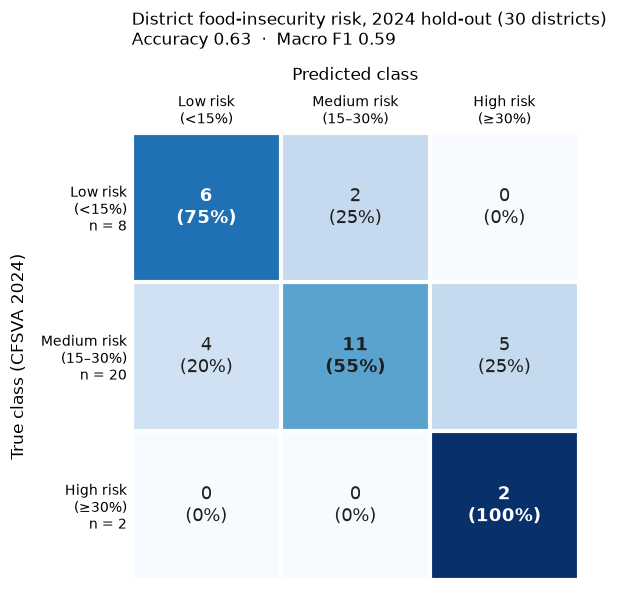

In [26]:
labels = ["low", "medium", "high"]
names = ["Low risk\n(<15%)", "Medium risk\n(15–30%)", "High risk\n(≥30%)"]

cm = confusion_matrix(test[TARGET], pred, labels=labels)
row_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=100)

for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if row_pct[i, j] > 60 else "#1f1f1f"
        ax.text(j, i, f"{cm[i, j]}\n({row_pct[i, j]:.0f}%)",
                ha="center", va="center", fontsize=13, color=color,
                fontweight="bold" if i == j else "normal")

ax.set_xticks(range(3), names, fontsize=10)
ax.set_yticks(range(3), [f"{n}\nn = {cm[i].sum()}" for i, n in enumerate(names)], fontsize=10)
ax.set_xlabel("Predicted class", fontsize=12, labelpad=10)
ax.set_ylabel("True class (CFSVA 2024)", fontsize=12, labelpad=10)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

acc = accuracy_score(test[TARGET], pred)
f1 = f1_score(test[TARGET], pred, average="macro")
ax.set_title(f"District food-insecurity risk, 2024 hold-out (30 districts)\n"
             f"Accuracy {acc:.2f}  ·  Macro F1 {f1:.2f}",
             fontsize=12, pad=16, loc="left")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, 3), minor=True)
ax.set_yticks(np.arange(-0.5, 3), minor=True)
ax.grid(which="minor", color="white", linewidth=3)
ax.tick_params(which="both", length=0)

plt.tight_layout()
plt.savefig("confusion_matrix_2024.png", dpi=200, bbox_inches="tight")
plt.show()


Feature importance shows the baseline relies mainly on district identity and province (62%), reflecting the structural nature of food insecurity in Rwanda. Next, we will rmeove district identifiers and model year-to-year change, so predictions respond to rainfall, price and harvest shocks

## Experiments with TensorBoard logging

This section compares short placeholder runs of the baseline and logs each one to TensorBoard. Each run trains CatBoost for only 50 iterations: the goal is to show that the pipeline works end to end, not to produce a final model. We test two ideas from the baseline. First, adding each district's food insecurity at its previous survey (`last_survey_food_insecure_pct`), which is known before the target year and is safe to use. Second, removing `province` and `district`, because the baseline relied on them for 62% of its feature importance, so its predictions reflect where a district is rather than its rain, prices and harvests. All runs use the baseline's split: train up to 2019, validate on the 2021 survey and test on the 2024 survey. A persistence baseline, where each district keeps its last survey class, is the minimum a model must beat.


In [27]:
# last_survey_food_insecure_pct was removed in cleaning: take it back from the original file
last = pd.read_csv("food_security_dataset.csv", usecols=["year", "district", "last_survey_food_insecure_pct"])
train_exp = train.merge(last, on=["year", "district"], how="left")
valid_exp = valid.merge(last, on=["year", "district"], how="left")
test_exp = test.merge(last, on=["year", "district"], how="left")

In [28]:
def score(y_true, y_pred):
    """Return accuracy, macro F1, and recall and precision on the high class."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "high_recall": recall_score(y_true, y_pred, labels=["high"], average="macro", zero_division=0),
        "high_precision": precision_score(y_true, y_pred, labels=["high"], average="macro", zero_division=0),
    }

In [29]:
def log_run(name, model, metrics, y_true, y_pred, params):
    """Write one experiment's training curves, test scores, confusion matrix and settings to runs/<name>."""
    writer = SummaryWriter(f"runs/{name}")
    # loss and macro F1 at every iteration, for train ("learn") and validation
    for split_name, curves in model.get_evals_result().items():
        for metric_name, values in curves.items():
            for step, value in enumerate(values):
                writer.add_scalar(f"{metric_name.split(':')[0]}/{split_name}", value, step)
    # final scores on the 2024 survey
    for key, value in metrics.items():
        writer.add_scalar(f"test_2024/{key}", value, params["iterations"])
    # confusion matrix as an image (reuses `labels` from the cell above)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks(range(3), labels)
    ax.set_yticks(range(3), labels)
    writer.add_figure("test_2024/confusion_matrix", fig)
    # settings and the results they gave (HParams tab)
    writer.add_hparams(params, {f"hparam/{k}": v for k, v in metrics.items()})
    writer.close()

In [30]:
def run_experiment(name, feature_list, cat_features, iterations=50):
    """Train a short CatBoost placeholder run, log it to TensorBoard and return its 2024 scores."""
    model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="TotalF1:average=Macro",
        iterations=iterations,
        learning_rate=0.05,
        depth=4,
        auto_class_weights="SqrtBalanced",
        random_seed=42,
        train_dir=f"catboost_logs/{name}",
        verbose=False,
    )
    model.fit(Pool(train_exp[feature_list], train_exp[TARGET], cat_features=cat_features),
              eval_set=Pool(valid_exp[feature_list], valid_exp[TARGET], cat_features=cat_features))
    pred_exp = model.predict(test_exp[feature_list]).ravel()
    metrics = score(test_exp[TARGET], pred_exp)
    params = {"iterations": iterations, "n_features": len(feature_list), "uses_location": bool(cat_features)}
    log_run(name, model, metrics, test_exp[TARGET], pred_exp, params)
    return {"experiment": name, **metrics}

In [31]:
# persistence baseline: each district keeps its class from the last survey (no model)
persistence = pd.cut(test_exp["last_survey_food_insecure_pct"], [-np.inf, 15, 30, np.inf],
                     right=False, labels=labels).astype(str)
results = [{"experiment": "baseline_persistence", **score(test_exp[TARGET], persistence)}]

no_location = [f for f in features if f not in CAT_FEATURES]
last_survey = ["last_survey_food_insecure_pct"]

results += [
    run_experiment("exp1_placeholder", features, CAT_FEATURES),
    run_experiment("exp2_last_survey", features + last_survey, CAT_FEATURES),
    run_experiment("exp3_no_location", no_location, []),
    run_experiment("exp4_last_survey_no_location", no_location + last_survey, []),
]
pd.DataFrame(results).round(3)

,experiment,accuracy,macro_f1,high_recall,high_precision
0,baseline_persistence,0.700,0.604,0.5,0.200
1,exp1_placeholder,0.600,0.521,0.5,0.167
2,exp2_last_survey,0.600,0.528,0.5,0.143
3,exp3_no_location,0.600,0.419,0.0,0.000
4,exp4_last_survey_no_location,0.667,0.474,0.0,0.000


### What the experiments show

None of the placeholder runs beats the persistence baseline (accuracy 0.70, macro F1 0.60): food insecurity changes slowly, so a district's class at its last survey is still the strongest predictor. Removing `province` and `district` lowers macro F1 from 0.52 to 0.42 and the model misses both High districts (Nyamagabe and Nyamasheke), which confirms that the baseline depends on location rather than on rainfall, price and harvest shocks. Adding the previous survey value helps only slightly (macro F1 0.52 to 0.53 with location, 0.42 to 0.47 without). In TensorBoard the training loss is still falling at iteration 50, as expected for a short placeholder run, while the validation F1 of experiments 2 to 4 peaks early and then drops, an early sign of overfitting. With only 30 test districts and 2 High cases, one district changes High recall by 0.5, so these results guide the next step rather than settle it. Next, we will train for more iterations and tune the class weights so the model predicts High more reliably.
